<h1 style="text-align: center;"> Multiclass/label Classification Practice </h1>

<h2> Importing required packages </h2>

In [1]:
### importing required packages
#setup package auto reload to minimize risks of running outdated external modules  
%load_ext autoreload
%autoreload 2

# importing files from src directory
import sys  
sys.path.insert(0, '../src')

# mu util class
from utils import Utils
util = Utils()


# local file links
from IPython.display import FileLink, FileLinks
FileLink('../docs/SMOTE.pdf')




# panda for data peocession
import pandas as pd
# setup Pandas
pd.set_option('display.width', 600)

# numpy for data wrangling
import numpy as np

# seaborn for data visulization
# why I use seaborn with matplotlib? 
# https://analyticsindiamag.com/comparing-python-data-visualization-tools-matplotlib-vs-seaborn/#:~:text=Matplotlib%3A%20Matplotlib%20is%20mainly%20deployed,has%20easily%20interesting%20default%20themes.
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
# setup seaborn
sns.set_style("whitegrid")

#ipython disply for better dataframe prints
from IPython.display import display, HTML


#pprint for better look print statements
import pprint


# pandas profiling package for a deep and quick look at features
from pandas_profiling import ProfileReport



# sklearn for modeling
import sklearn as sklearn

# train/test split
from sklearn.model_selection import train_test_split



<h2> Loading Modeling Ready features and labels </h2>

In [2]:
#loading csv data files into pandas data frames

#A- why my first choice is 'c' vs 'python' for data parser engine?
#https://stackoverflow.com/questions/52774459/engines-in-python-pandas-read-csv
#B- using infer_datetime_format to convert string date feature to date datatype on loading
#C- verbose allows to early detect data or memory issues
#we can see below that one of the collumns have mixed datatypes
X = pd.read_csv('../data/X.csv',engine = 'c', infer_datetime_format = True, verbose = True, index_col='index', encoding = 'utf-8')
y = pd.read_csv('../data/y.csv',engine = 'c', infer_datetime_format = True, verbose = True,  index_col='index', encoding = 'utf-8')

# QA
print(y.shape)
print(X.shape)

Tokenization took: 31.03 ms
Type conversion took: 32.84 ms
Parser memory cleanup took: 0.01 ms
Tokenization took: 14.29 ms
Type conversion took: 27.76 ms
Parser memory cleanup took: 0.01 ms
Tokenization took: 13.07 ms
Type conversion took: 27.86 ms
Parser memory cleanup took: 0.01 ms
Tokenization took: 10.32 ms
Type conversion took: 21.31 ms
Parser memory cleanup took: 0.01 ms
Tokenization took: 5.19 ms
Type conversion took: 2.28 ms
Parser memory cleanup took: 0.01 ms
(30791, 1)
(30791, 108)


> quick look at target and features

In [3]:
#looking at the data we loaded - labels
display(HTML(y[:10].to_html()))

,status_group
index,
69572,functional
34310,functional
67743,non functional
9944,functional
49056,functional
50409,functional
50495,functional
61848,functional
48451,non functional


In [4]:
#looking at the data we loaded - feaures
display(HTML(X[:10].to_html()))

,amount_tsh,gps_height,population,construction_year,year,month,day,funder_District Council,funder_Kkkt,funder_Tasaf,funder_Unicef,funder_World Vision,funder_danida,funder_gov,funder_hesawa,funder_other,funder_rwssp,funder_world_bank,installer_danida,installer_dwe,installer_gov,installer_hesawa,installer_kkkt,installer_other,installer_rwe,installer_tcrs,wpt_name_Bombani,wpt_name_Kanisani,wpt_name_Msikitini,wpt_name_Ofisini,wpt_name_Sekondari,wpt_name_Shule Ya Msingi,wpt_name_Shuleni,wpt_name_Sokoni,wpt_name_Zahanati,wpt_name_none,wpt_name_other,basin_Internal,basin_Lake Nyasa,basin_Lake Rukwa,basin_Lake Tanganyika,basin_Lake Victoria,basin_Pangani,basin_Rufiji,basin_Ruvuma / Southern Coast,basin_Wami / Ruvu,public_meeting_False,public_meeting_True,scheme_management_Parastatal,scheme_management_company,scheme_management_other,scheme_management_pri_optr,scheme_management_trust,scheme_management_vwc,scheme_management_wtr_auth,scheme_management_wtr_brd,scheme_management_wua,scheme_management_wug,permit_False,permit_True,extraction_type_class_gravity,extraction_type_class_handpump,extraction_type_class_motorpump,extraction_type_class_other,extraction_type_class_rope pump,extraction_type_class_submersible,extraction_type_class_wind-powered,management_group_commercial,management_group_other,management_group_parastatal,management_group_unknown,management_group_user-group,payment_type_annually,payment_type_monthly,payment_type_never pay,payment_type_on failure,payment_type_other,payment_type_per bucket,payment_type_unknown,water_quality_coloured,water_quality_fluoride,water_quality_fluoride abandoned,water_quality_milky,water_quality_salty,water_quality_salty abandoned,water_quality_soft,water_quality_unknown,quantity_group_dry,quantity_group_enough,quantity_group_insufficient,quantity_group_seasonal,quantity_group_unknown,source_class_groundwater,source_class_surface,source_class_unknown,waterpoint_type_group_cattle trough,waterpoint_type_group_communal standpipe,waterpoint_type_group_dam,waterpoint_type_group_hand pump,waterpoint_type_group_improved spring,waterpoint_type_group_other,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
index,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
69572,6000.0,1390.0,109.0,1999.0,2011,3,14,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
34310,25.0,686.0,250.0,2009.0,2013,2,25,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0
67743,0.0,263.0,58.0,1986.0,2013,1,28,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
9944,20.0,0.0,1.0,2009.0,2011,3,13,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0
49056,0.0,62.0,345.0,2011.0,2011,2,20,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0
50409,200.0,1062.0,250.0,1987.0,2013,2,18,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0
50495,0.0,1368.0,1.0,2009.0,2013,3,15,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,

<h2>Splitting dataset (train, validation, and test)</h2>
<p>
<mark> holding out 30% of the date to use it for model accuracy comparision and keeping 60% as train and validation  </mark>
</p>

In [5]:
# holding out one third of the date to use it for model accuracy comparision
# and keeping tow thirds as train and validation 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, shuffle=True)

In [6]:
#QA
print (X_train.shape)
print (y_train.shape)
print (X_test.shape)
print (y_test.shape)


(21553, 108)
(21553, 1)
(9238, 108)
(9238, 1)


<h2> Handling imbalanced classes discussed earlier in the exploratory data analysis </h2>

<p> <mark>As discussed in data exploration we will use SMOTE oversampling to handle class imbalance without losing informaton by down sampling or duplicating the data by upsampling. </mark>
</p>


functional                 12301
non functional              7759
functional needs repair     1493
Name: status_group, dtype: int64

 

functional                 0.570733
non functional             0.359996
functional needs repair    0.069271
Name: status_group, dtype: float64


<AxesSubplot:title={'center':'Status Group Classes'}, xlabel='status_group', ylabel='count'>

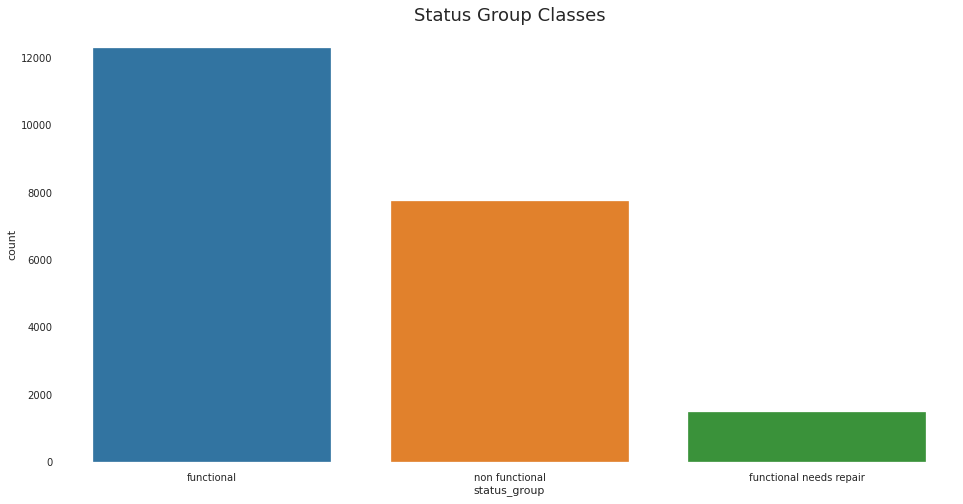

In [7]:
# training set class balance
print (y_train['status_group'].value_counts())
print ("\n \n")

# data points percentage of each class 
print (y_train['status_group'].value_counts()/len(y_train['status_group']))
# bar plot of classes
plt.figure(figsize=(16,8))
plt.title("Status Group Classes",fontsize=18)
sns.countplot(y_train['status_group'])



<h3>balancing using SMOTE only</h3>

Counter({'status_group': 1})
non functional             12301
functional needs repair    12301
functional                 12301
Name: status_group, dtype: int64

 

non functional             0.333333
functional needs repair    0.333333
functional                 0.333333
Name: status_group, dtype: float64


<AxesSubplot:title={'center':'Status Group Classes'}, xlabel='status_group', ylabel='count'>

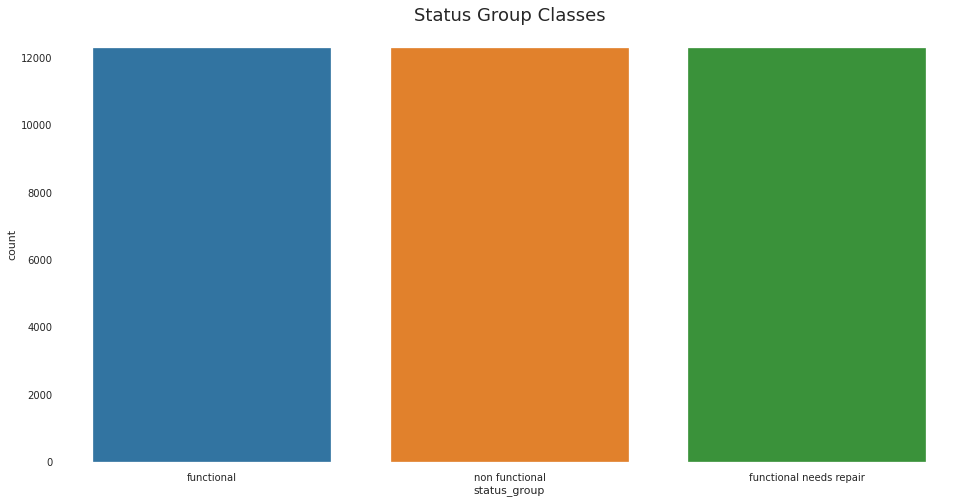

In [10]:
# Oversample with SMOTE
from collections import Counter

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline


# summarize class distribution
counter = Counter(y)
print(counter)

# define pipeline

# total balance 1:1
over = SMOTE()
# over = SMOTE('minority')

steps = [('o', over)]
pipeline = Pipeline(steps=steps)

# transform the dataset
X_train_SMOTE, y_train_SMOTE = pipeline.fit_resample(X_train, y_train)

# QA class distribution
# training set class balance
print (y_train_SMOTE['status_group'].value_counts())
print ("\n \n")

# data points percentage of each class 
print (y_train_SMOTE['status_group'].value_counts()/len(y_train_SMOTE['status_group']))
# bar plot of classes
plt.figure(figsize=(16,8))
plt.title("Status Group Classes",fontsize=18)
sns.countplot(y_train_SMOTE['status_group'])



<h3> balancing using Under-sampling and SMOTE Combination </h3>
<p> As reported in <a href="http://localhost:8888/files/docs/SMOTE.pd">SMOTE</a> paper, it is believed that SMOTE performs better when combined with undersampling of the majority class, such as random undersampling.
</p>


non functional             7759
functional needs repair    7759
functional                 7759
Name: status_group, dtype: int64

 

non functional             0.333333
functional needs repair    0.333333
functional                 0.333333
Name: status_group, dtype: float64


<AxesSubplot:title={'center':'Status Group Classes'}, xlabel='status_group', ylabel='count'>

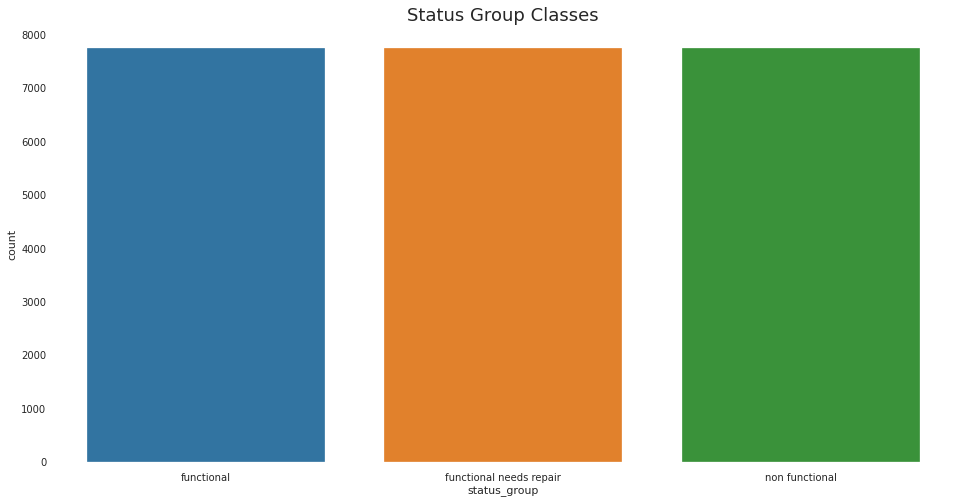

In [11]:
# Oversample with SMOTE and random undersample
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# define pipeline
over = SMOTE(sampling_strategy='minority')
under = RandomUnderSampler(sampling_strategy='not minority')
steps = [('o', over), ('u', under)]
pipeline = Pipeline(steps=steps)

# transform the dataset
X_train_ou, y_train_ou = pipeline.fit_resample(X_train, y_train)

# QA class distribution
# training set class balance
print (y_train_ou['status_group'].value_counts())
print ("\n \n")

# data points percentage of each class 
print (y_train_ou['status_group'].value_counts()/len(y_train_ou['status_group']))
# bar plot of classes
plt.figure(figsize=(16,8))
plt.title("Status Group Classes",fontsize=18)
sns.countplot(y_train_ou['status_group'])


<h3> Balancing methodology for the round 1 model training </h3>
<p>
<mark>I will start with SMOTE for the 1st round modeling attempts</mark>
</p>

<h2>Decision Tree Classifier</h2>
<p> Decision Tree Algorithem is my 1st attempt due to the following:
<ul>
    <li> <mark><b>speed</b></mark> quick to try</li>
    <li> <mark><b>explainability</b></mark> can bring intersting finiding to my attention that leads to better understanding and modeling of the data </li> 
</ul>
    
    
</p>

<h3>Data balanced by over sampling [SMOTE]</h3>

<h4> cross validation </h4>
<p> <mark>I prefer the repeated stratified cross validation as it assure equality of classess represntation among all test samples which prduce more robust accuracy mesures </mark></p>

In [17]:
# importing model selection packages
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score

# define model - default parameters
dtc = DecisionTreeClassifier()

# evaluate pipeline
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
scores = cross_val_score(dtc, X_train_SMOTE, y_train_SMOTE, scoring='accuracy', cv=cv, n_jobs=-1)

In [ ]:
print(scores)


In [18]:
# mean accuracy between the folds
print('Mean Accuracy: %.3f' % np.mean(scores))


Mean Accuracy: 0.811


<h4> model training </h4>

In [20]:
from sklearn.tree import DecisionTreeClassifier


# default no hyperparameter tuning
dtc = DecisionTreeClassifier()
dtc.fit(X_train_SMOTE, y_train_SMOTE)

DecisionTreeClassifier()

<h4> model accuracy </h4>

<h5>simple accuracy</h5>

In [21]:
print("Train Score :", dtc.score(X_train_SMOTE, y_train_SMOTE))
print("Test Score :", dtc.score(X_test, y_test))

Train Score : 0.9991328618269517
Test Score : 0.7364148084000866


<h5> difference between performance using test, and performance using cross validation </h5>
<p>
<mark>
Cross validation reached 81% accuracy that is 7% more acurate than the one segemnt validation training.
</mark>
<br>
<mark>
this is due to the ability for the model to learn better using the cross validation process.
</mark>
</p>

<h5>important features</h5>
<p> <mark>following are the importnat features - not very surprising and was expected </mark></p>



In [22]:
 

#feature importance
sorted_importance = dtc.feature_importances_

# printing sorded feature names and importance score
for f in range(0,len(sorted_importance)):

    print (X_train_SMOTE.columns[f] +' : '+ str(sorted_importance[f]) )
    

amount_tsh : 0.04016942047726349
gps_height : 0.16101506892836118
population : 0.09525697241102941
construction_year : 0.08189117828813271
year : 0.00841844217988668
month : 0.031485931623571425
day : 0.043600963227504494
funder_District Council : 0.0005924853328616253
funder_Kkkt : 0.0005289795881175893
funder_Tasaf : 0.0006069173272496512
funder_Unicef : 0.0022372409742647185
funder_World Vision : 0.0009417846548495374
funder_danida : 0.004510364681125901
funder_gov : 0.005532450030851186
funder_hesawa : 0.0
funder_other : 0.011494851593695685
funder_rwssp : 0.0
funder_world_bank : 0.0012893211385986366
installer_danida : 0.00014942126268181237
installer_dwe : 0.007929214122386933
installer_gov : 0.0003772651983738077
installer_hesawa : 7.564390218894175e-05
installer_kkkt : 0.0002834580854408746
installer_other : 0.010404667304443962
installer_rwe : 0.0010823626395016863
installer_tcrs : 0.0004474853251312034
wpt_name_Bombani : 0.00022025240625247734
wpt_name_Kanisani : 0.0004850078

<h5>Multi class Confusion Matrix for determnig model accuracy</h5>
<p> Explainations of metrices:
<ul>
<li>Precision = TruePositives / (TruePositives + FalsePositives)</li>

<li>Recall = TruePositives / (TruePositives + FalseNegatives)</li>

<li>F1-score = (2 * Precision * Recall) / (Precision + Recall))</li>

</ul>
<br>
<br>
<b>Increasing Precision:</b> Appropriate when minimizing false positives is the focus.
<br>
<br>
<b>Increasing Recall:</b> Appropriate when minimizing false negatives is the focus.
<br>
<br>
<b>F1-score:</b> Is the harmonic mean of the two fractions. 
<p>

In [23]:
from sklearn.metrics import classification_report

# predection accuracy using precesion/recall/f1-score and over all accuracy
y_predicted = dtc.predict(X_test)
report = classification_report(y_test, y_predicted)
print(report)



                         precision    recall  f1-score   support

             functional       0.80      0.78      0.79      5261
functional needs repair       0.32      0.36      0.34       655
         non functional       0.73      0.74      0.73      3322

               accuracy                           0.74      9238
              macro avg       0.62      0.63      0.62      9238
           weighted avg       0.74      0.74      0.74      9238



Confusion matrix
[[4099  360  802]
 [ 294  237  124]
 [ 711  144 2467]]


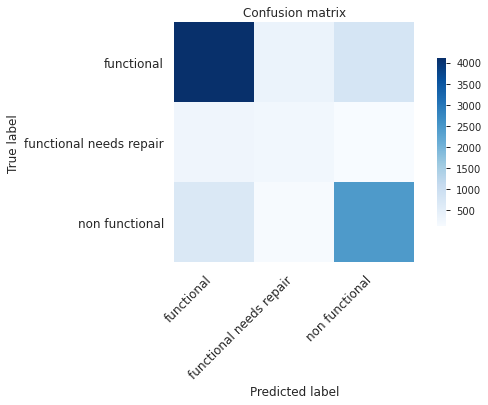

In [24]:
## visual Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, dtc.predict(X_test))
np.set_printoptions(precision=2)
print('Confusion matrix')
print(cm)
plt.figure()
util.plot_confusion_matrix(cm)

<p> 
<b>commenting on accuracy results</b>
<br> 
<br> 
<mark>
the model is doing well for a crude quick model, inspite of it is stll confused about the minority class 'functional needs repair', as a future work I would carry out more work on the class balancing e.g. trying the hyprid over and down sampling method to increase the model ability to discriminate better between classes
</mark>
</p>


<h5>Comparing models</h5>
<p>
 Given more time I would intensivly try more (models - grid search for HP tuning - stratifiedKFolds)
 and would compare them using the following sample code
</p>

In [ ]:

# Compare Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


# prepare configuration for cross validation test harness
seed = 7
# prepare models
models = []
models.append(('LR', LogisticRegression()))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))

# evaluate each model in turn
results = []
names = []
scoring = 'accuracy' 
for name, model in models:
    kfold = model_selection.KFold(n_splits=10, random_state=seed)
    cv_results = model_selection.cross_val_score(model, X_train_SMOTE, y_train_SMOTE, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)
    
# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

<h5>Saving the model</h5>

> lets save the model for later

In [32]:
import joblib 
  
# Save the model as a pickle in a file 
joblib.dump(dtc, '../models/dtc.pkl') 
  
# how to load
# dtc_old = joblib.load('../models/dtc.pkl')  
  
# Use the loaded model to make predictions 
# dtc_old.predict(X_test) 


['../models/dtc.pkl']

<h1> Future Work: </h1>

<p>
<ul>

<li> <b>Further Feature Engineering to increase model learning abilities  </b>
<ul>
<li> closer look at high importance features and invistigate/debug them further </li>
<li>bringing/enriching more features about the problem e.g. pump age </li>
<li>debuging the population feature values e.g. scraping latest Population statistics for those areas </li>
<li>using the geolocation features that I have discared e.g. regoin, longitude, latitude</li>
<li>using feature hashing scheme for categorical feature encoding for high arity/cardinality features </li>
<li>creating granularity maps for parent/child features to use it for future missing data filling on predection vectors</li>
<li>using predection/statistical methodology for filling missing data instead of the crude way I used by droping all rows that have missing data - <b>due to time and space limitations</b></li>  
 
 <li>handling multicoliniarity differently e.g. using PCA instead of droping the features</li>
</ul>
</li>
   
<br>   
<li><b> Further Work on Modeling </b>
<ul>
<li>Grid Search for hyperparameters tuning </li>
<li>Testing more models and compare them</li>   
<li>ROC/AUC for determnig model accuracy by binarizing the classes and using one vs all approach to generate roc for each class</li>
</ul>
</li>
 
<br>   
<li><b>Further Work on Class Balancing </b>
<ul>
<li>Trying the hypered over/down sampling methodology to increase model accuracy on minority class </li>
</ul>
</li>
  
<br>   
<li><b> Further Work on Visulization </b>
<ul>
<li>location visulaization for mining interesting findings about  pump functionality status and location</li>
<li>extra visulization for feature importance</li>
</ul>
</li>
 
<br>   
<li><b> Further Work on Reproduceability of the pipeline </b>
<ul>
<li>a robust software engineering upgrade of the code i.e more object orinted approach</li>
</ul>
</li>
    

</ul>
</p>

<h1>Refrences:</h1>

<p>
<ul>
<li>https://towardsdatascience.com/understanding-auc-roc-curve-68b2303cc9c5</li>
<li>https://analyticsindiamag.com/5-ways-handle-missing-values-machine-learning-datasets/</li>
<li>https://towardsdatascience.com/understanding-feature-engineering-part-2-categorical-data-f54324193e63</li>
<li>https://shiring.github.io/machine_learning/2017/04/02/unbalanced#:~:text=In%20this%20context%2C%20unbalanced%20data,control%20samples%20than%20disease%20cases.</li>
<li>https://medium.com/@b.terryjack/tips-and-tricks-for-multi-class-classification-c184ae1c8ffc</li>
<li>https://towardsdatascience.com/machine-learning-multiclass-classification-with-imbalanced-data-set-29f6a177c1a</li>
<li>https://blogs.sas.com/content/subconsciousmusings/files/2017/04/machine-learning-cheet-sheet-2.png</li>
<li>https://stackoverflow.com/questions/45332410/sklearn-roc-for-multiclass-classification</li>
<li>https://machinelearningmastery.com/compare-machine-learning-algorithms-python-scikit-learn/</li>
<li>https://datascience.stackexchange.com/questions/24452/in-supervised-learning-why-is-it-bad-to-have-correlated-features</li>

    
</ul>
</p>